Segment
At Risk            1611.350915
Champions          7526.221513
Loyal Customers    2213.587400
Others              584.838738
Name: Monetary, dtype: float64

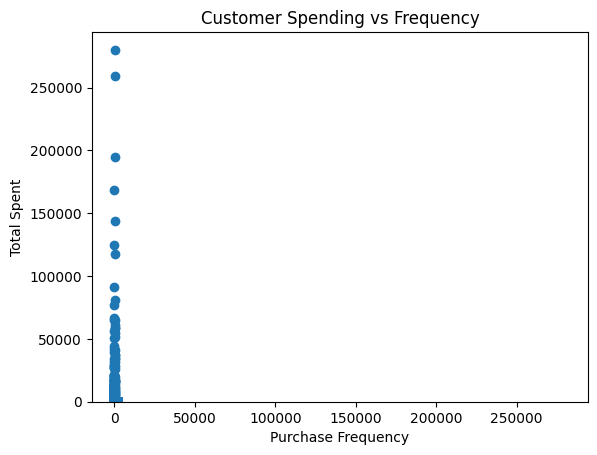

In [10]:
import pandas as pd
df= pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
df.head()

#Remove missing Customer IDs and canceled orders (negative quanity)
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]

#Create total price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

#Revenue per customer
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_revenue = customer_revenue.sort_values(by = 'TotalPrice', ascending=False)
customer_revenue.head()

#Purchase frequency
customer_freq = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_freq.columns = ['CustomerID', 'PurchaseFrequency']

customer_data = pd.merge(customer_revenue, customer_freq, on='CustomerID')
customer_data.head()
customer_data.corr()

import matplotlib.pyplot as plt

customer_data['TotalPrice'].describe()
plt.hist(customer_data['TotalPrice'], bins=50)
plt.title('Distribution of Customer Spending')
#plt.show()

filtered = customer_data[customer_data['TotalPrice'] < 10000]
plt.scatter(customer_data['PurchaseFrequency'], customer_data['TotalPrice'])
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spent')
plt.title('Customer Spending vs Frequency')
#plt.show()

#Segmenting data
q1 = customer_data['PurchaseFrequency'].quantile(0.25)
q3 = customer_data['PurchaseFrequency'].quantile(0.75)

def segment(x):
    if x <= q1:
        return 'Low'
    elif x <= q3:
        return 'Medium'
    else:
        return 'High'

customer_data['Segment'] = customer_data['PurchaseFrequency'].apply(segment)
#customer_data.groupby('Segment')['TotalPrice'].mean()

#Do high frequency customers spend consistently?
#customer_data.groupby('Segment')['TotalPrice'].describe()

#Creating RFM Model
#Create R (Recency)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

snapshot_date = df['InvoiceDate'].max()
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (snapshot_date - recency['InvoiceDate']).dt.days
recency = recency[['CustomerID', 'Recency']]

#Create F (Frequency)
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID', 'Frequency']

#Create Monetary
monetary = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']

#Merge everything
rfm = recency.merge(frequency, on='CustomerID').merge(monetary, on='CustomerID')
rfm.head()

#Score each metric
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

#Combine into RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)
rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)

#Create customer segments
def segment(row):
    if row['R_Score'] == 4 and row['F_Score'] == 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Others'
rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

#Segment calculations
#rfm['Segment'].value_counts()
#rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
rfm.groupby('Segment')['Monetary'].mean()

#customer_data['CustomerType'] = customer_data['PurchaseFrequency'].apply(lambda x: 'High Frequency' if x > 5 else 'Low Frequency')
#customer_data.groupby('CustomerType')['TotalPrice'].mean()